In [ ]:
pip install fredapi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import warnings

fred_key="_"


warnings.filterwarnings("ignore")

In [ ]:
# 1. Data Acquisition
fred = Fred(api_key=fred_key)

# CPIAUCSL: Consumer Price Index for All Urban Consumers (Monthly)
series_id = 'CPIAUCSL'
raw_data = fred.get_series(series_id)

df = pd.DataFrame(raw_data, columns=['value']).loc['2015-01-01':]
df.index.name = 'Date'

df = df.dropna()

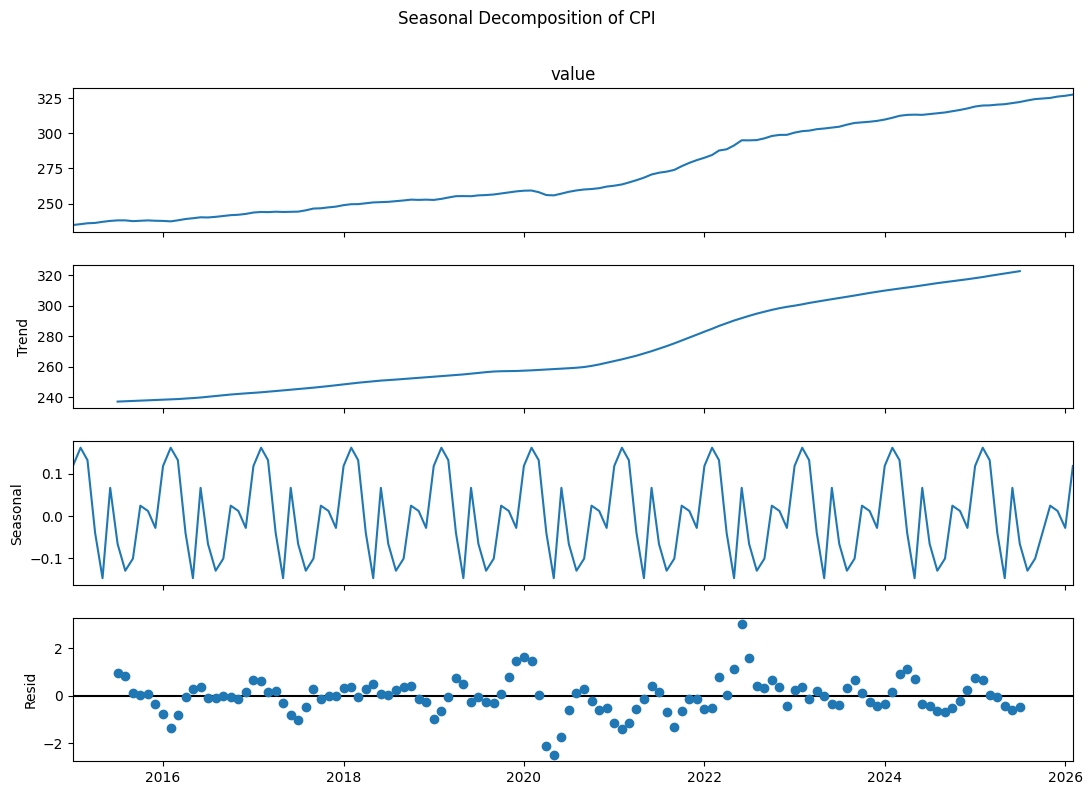

In [ ]:
# 2. Seasonal Decomposition
decomposition = seasonal_decompose(df['value'], model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Seasonal Decomposition of CPI', y=1.02)
plt.show()

In [ ]:
# 3. Train-Test-split

train_size = int(len(df) * 0.85)
train, test = df['value'][:train_size], df['value'][train_size:]

In [ ]:
# 4. Model Evaluation
def evaluate_model(train_data, test_data, order, seasonal_order=None):
    history = [x for x in train_data]
    predictions = []

    for t in range(len(test_data)):
        if seasonal_order:
            model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            model_fit = model.fit(disp=False)
        else:
            model = ARIMA(history, order=order)
            model_fit = model.fit() # Removed disp=False for ARIMA

        yhat = model_fit.forecast()[0]
        predictions.append(yhat)
        history.append(test_data.iloc[t])

    rmse = np.sqrt(mean_squared_error(test_data, predictions))
    return predictions, rmse

In [ ]:
# 5. Model Training

print("Training ARIMA(1,1,1)...")
arima_preds, arima_rmse = evaluate_model(train, test, (1, 1, 1))

print("Training SARIMA(1,1,1)x(1,1,1,12)...")
sarima_preds, sarima_rmse = evaluate_model(train, test, (1, 1, 1), (1, 1, 1, 12))

Training ARIMA(1,1,1)...
Training SARIMA(1,1,1)x(1,1,1,12)...



--- Performance Comparison ---
ARIMA RMSE:  0.3688
SARIMA RMSE: 0.4609


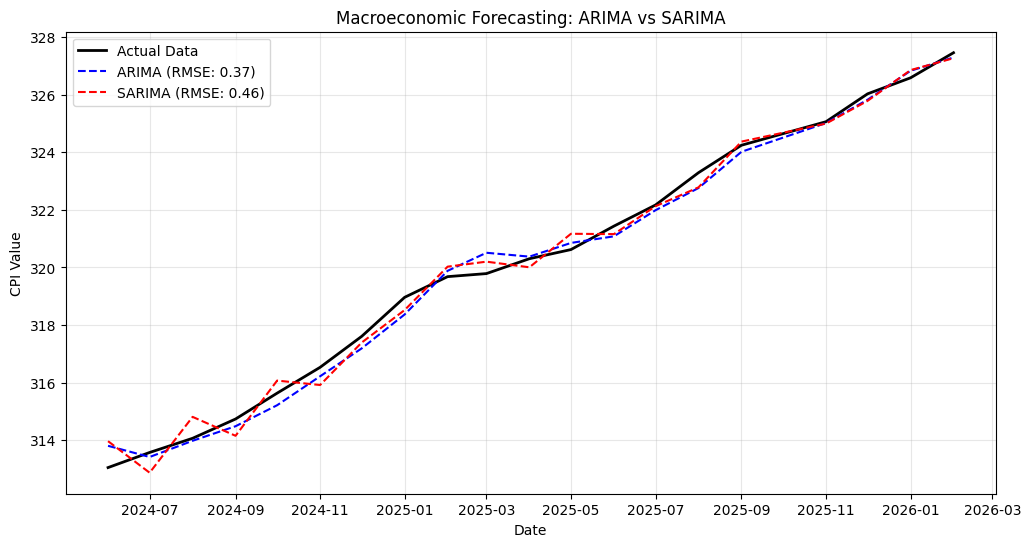

In [ ]:
# 6. Results and Comparison
print(f"\n--- Performance Comparison ---")
print(f"ARIMA RMSE:  {arima_rmse:.4f}")
print(f"SARIMA RMSE: {sarima_rmse:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual Data', color='black', linewidth=2)
plt.plot(test.index, arima_preds, label=f'ARIMA (RMSE: {arima_rmse:.2f})', linestyle='--', color='blue')
plt.plot(test.index, sarima_preds, label=f'SARIMA (RMSE: {sarima_rmse:.2f})', linestyle='--', color='red')

plt.title('Macroeconomic Forecasting: ARIMA vs SARIMA')
plt.xlabel('Date')
plt.ylabel('CPI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


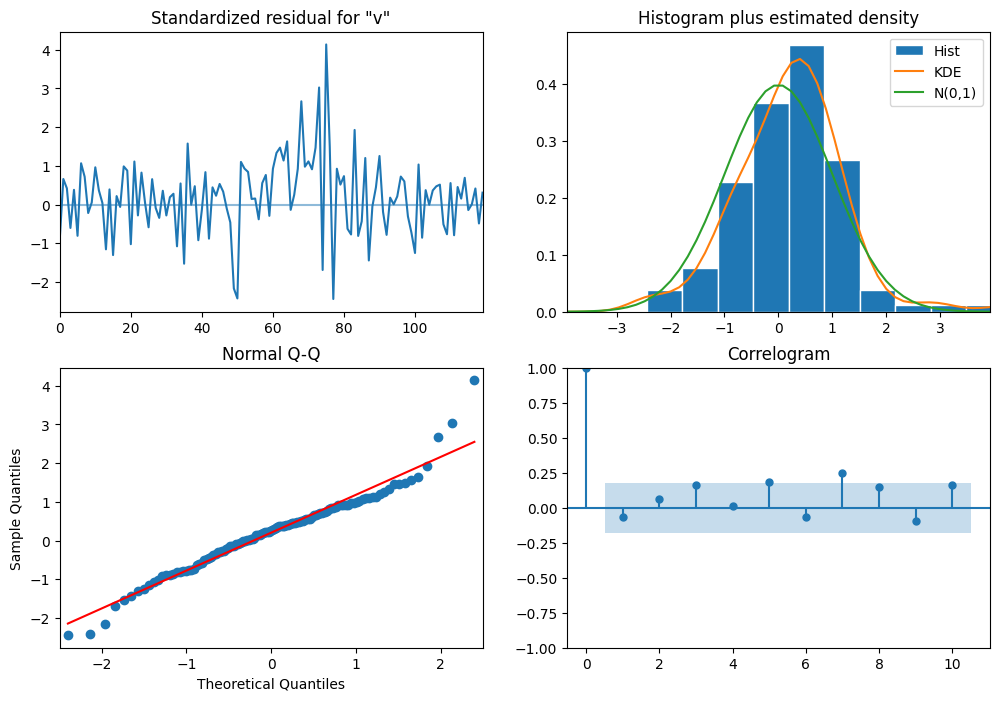

In [ ]:
# 7. Final Model Diagnostics
# Usually, SARIMA performs better on seasonal macro data
winning_model = SARIMAX(df['value'], order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
winning_model.plot_diagnostics(figsize=(12, 8))
plt.show()